In [3]:
import os 
import shutil
shutil.unpack_archive("ne_merged_refined_tile_jpg.zip", "ne_test_images")
shutil.unpack_archive("ne_refined_labels_for_yolo_segmentation.zip", "ne_test_labels")

print(f" Images :{len(os.listdir('ne_test_images'))}")
print(f" Test labels : {len(os.listdir('ne_test_labels'))}")

                    

 Images :1155
 Test labels : 104


In [4]:
base = "/home3/zpdv81/ne_test_dataset_for_detection"
os.makedirs(os.path.join(base,"images","test"),exist_ok = True)
os.makedirs(os.path.join(base,"labels","test"),exist_ok = True)


# copy image
for image in os.listdir("ne_test_images"):
    shutil.copy(os.path.join("ne_test_images" , image),os.path.join(base,"images","test",image))
    
for label in os.listdir("ne_test_labels"):
    shutil.copy(os.path.join("ne_test_labels",label),os.path.join(base,"labels","test",label))
    
print("files copied")

    

files copied


In [5]:
# create YOLO data.yaml file

data_yaml = f"""train: {base}/images/test

val: {base}/images/test
test: {base}/images/test

nc: 1
names:
      0: ridge_and_furrow
"""
yaml_path = os.path.join(base,"data.yaml")

with open(yaml_path,"w")as file:
    file.write(data_yaml)

print(f" data_yaml saved : {yaml_path}")



 data_yaml saved : /home3/zpdv81/ne_test_dataset_for_detection/data.yaml


In [11]:
import os
data_path = os.path.join(base,"data.yaml")

test_script = f'''
from ultralytics import YOLO
model = YOLO("/home3/zpdv81/yolo_runs_refined_checkboard/rnf_refined_yolo_segmentation_checkboard_2-2/weights/best.pt")
results = model.val(data = "{data_path}",plots = False)
'''
with open("/home3/zpdv81/test_ne.py","w")as f:
    f.write(test_script)
    
print("script written")






script written


In [12]:
!/home3/zpdv81/yolo_venv/bin/python /home3/zpdv81/test_ne.py

Ultralytics 8.4.110 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA A100 80GB PCIe MIG 1g.10gb, 9728MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 175.5±63.4 MB/s, size: 290.1 KB)
val: Scanning /home3/zpdv81/ne_test_dataset_for_detection/labels/test... 104 images, 1051 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1155/1155 1.7Kit/s 0.7s1s
val: New cache created: /home3/zpdv81/ne_test_dataset_for_detection/labels/test.cache
/home3/zpdv81/yolo_venv/lib/python3.8/site-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warnin

In [1]:
test_script = '''
from ultralytics import YOLO

model = YOLO("/home3/zpdv81/yolo_runs_refined_checkboard/rnf_refined_yolo_segmentation_checkboard_2-2/weights/best.pt")
results = model.predict(
      source = "/home3/zpdv81/ne_test_dataset_for_detection/images/test",
      save = True,
      conf = 0.25,
      project = "/home3/zpdv81/ne_prediction_for_ridge_and_furrow",
      name = "test_results"
)
total = 0
tiles = 0
for r in results:
    n = len(r.boxes)
    if n > 0:
        tiles +=1
        total += n
    
print(f" Total ridge and furrow detections : {total}")
print(f" Total tiles with detections : {tiles}")
print(f" Total tiles without detections: {1155 - tiles}")

'''
with open("/home3/zpdv81/test_ne.py","w") as f:
    f.write(test_script)

print("script written")






script written


In [2]:
!/home3/zpdv81/yolo_venv/bin/python /home3/zpdv81/test_ne.py


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1155 /home3/zpdv81/ne_test_dataset_for_detection/images/test/tile_0_0.jpg: 640x640 (no detections), 7.2ms
image 2/1155 /home3/zpdv81/ne_test_dataset_for_detection/images/test/tile_0_10240.jpg: 640x640 (no detections), 6.6ms
image 3/1155 /home3/zpdv81/ne_test_dataset_for_detection/images/test/tile_0_10880.jpg: 640x640 (no detections), 7.1ms
image 4/1155 /home3/zpdv81/ne_test_dataset_for_detection/images/test/tile_0_11520.jpg: 640x640 (no detection

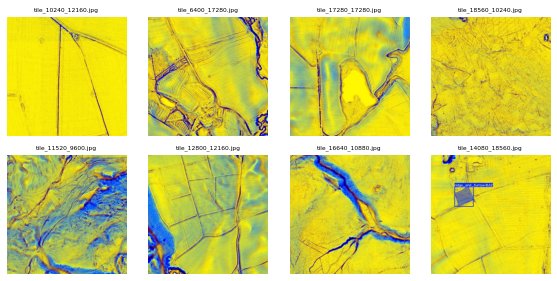

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
# folder with prediction images
pred_dir = "/home3/zpdv81/ne_prediction_for_ridge_and_furrow/test_results"

# first 8 images with detections
images = []
names = []
for f in os.listdir(pred_dir):
    if f.endswith(".jpg"):
        size = os.path.getsize(os.path.join(pred_dir,f))
        if size > 100000:
            a = Image.open(os.path.join(pred_dir,f)) 
            images.append(a)# add image to image list
            names.append(f) # add file name

            if len(images)==8:
                break
# plot in gird           
fig, axes = plt.subplots(2,4,figsize = (8,4))
for i in range(8):
    axes.flat[i].imshow(images[i])
    axes.flat[i].set_title(names[i],fontsize = 6)
    axes.flat[i].axis("off")
plt.tight_layout()

plt.savefig("test_detection_result_1.png", dpi = 300, bbox_inches = 'tight')
plt.show()